## **Growth Forecasting: Back to basics**

The author mentions Francis Galton (the same one with the bull).  
Galton studied how the height of parents affects the height of children.  

**Regression Line:** This is the line of "best fit" that runs through the cloud  
of points on a graph. It shows the overall trend.    
**Coefficients:** These are the numbers in the regression equation.  
For example, if the coefficient for the father's height is 0.6, this means that  
for every additional centimeter of the father's height, the child will be 0.6 cm taller,
on average.  

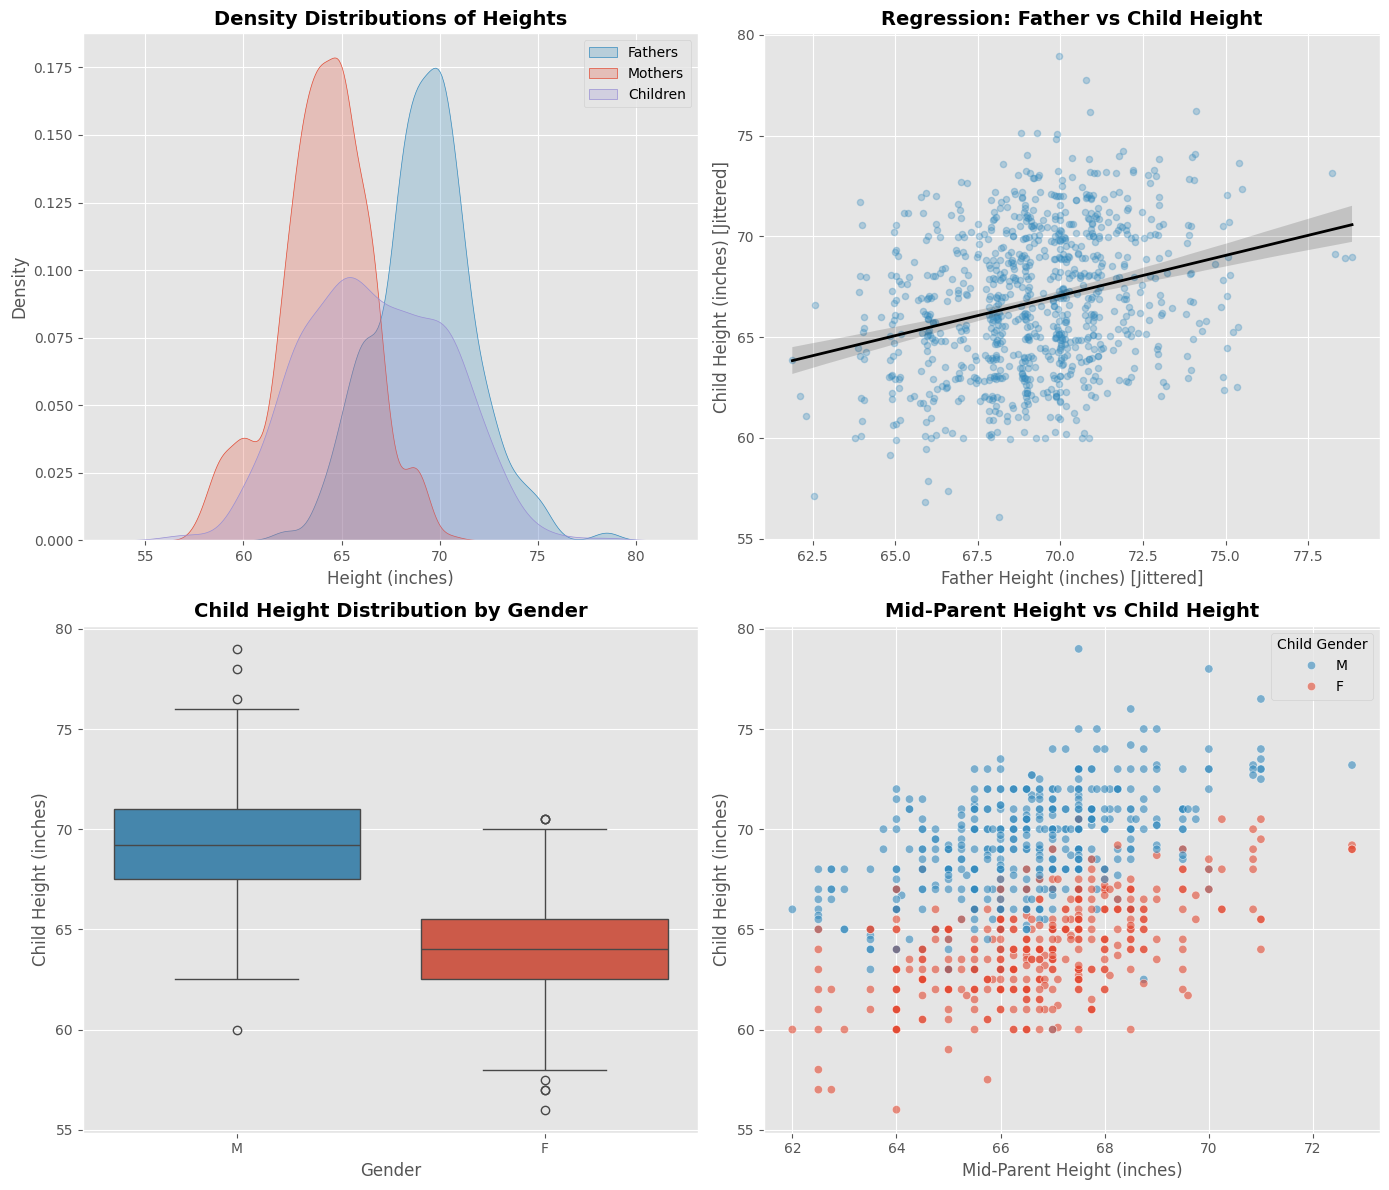

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set ggplot style for R-like aesthetics
plt.style.use('ggplot')

# Load the dataset
df = pd.read_csv('galton-x.csv')

# Calculate Mid-Parent Height (average of Father and Mother)
# Galton historically multiplied Mother's height by 1.08, but simple average is fine here
df['MidParent'] = (df['Father'] + df['Mother']) / 2

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# PLOT 1: Density Distributions of Heights
sns.kdeplot(data=df, x='Father', fill=True, color='#348ABD', label='Fathers', ax=axes[0, 0])
sns.kdeplot(data=df, x='Mother', fill=True, color='#E24A33', label='Mothers', ax=axes[0, 0])
sns.kdeplot(data=df, x='Height', fill=True, color='#988ED5', label='Children', ax=axes[0, 0])

axes[0, 0].set_title('Density Distributions of Heights', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Height (inches)', fontsize=12)
axes[0, 0].set_ylabel('Density', fontsize=12)
axes[0, 0].legend()


# PLOT 2: Regression (Father vs Child Height)
# Adding a tiny bit of random noise (jitter) because the data is highly discretized 
# (measured in exact inches), otherwise points overlap too much
jitter_x = df['Father'] + np.random.normal(0, 0.15, size=len(df))
jitter_y = df['Height'] + np.random.normal(0, 0.15, size=len(df))

sns.regplot(
    x=jitter_x, 
    y=jitter_y, 
    scatter_kws={'alpha': 0.3, 'color': '#348ABD', 's': 20}, 
    line_kws={'color': 'black', 'linewidth': 2},
    ax=axes[0, 1]
)

axes[0, 1].set_title('Regression: Father vs Child Height', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Father Height (inches) [Jittered]', fontsize=12)
axes[0, 1].set_ylabel('Child Height (inches) [Jittered]', fontsize=12)

# PLOT 3: Boxplot of Child Height by Gender
sns.boxplot(
    data=df, 
    x='Gender', 
    y='Height', 
    hue='Gender', 
    palette=['#348ABD', '#E24A33'], 
    ax=axes[1, 0]
)

axes[1, 0].set_title('Child Height Distribution by Gender', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Gender', fontsize=12)
axes[1, 0].set_ylabel('Child Height (inches)', fontsize=12)

# PLOT 4: Scatter Plot (Mid-Parent vs Child)
sns.scatterplot(
    data=df, 
    x='MidParent', 
    y='Height', 
    hue='Gender', 
    palette=['#348ABD', '#E24A33'], 
    alpha=0.6, 
    edgecolor='white',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Mid-Parent Height vs Child Height', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Mid-Parent Height (inches)', fontsize=12)
axes[1, 1].set_ylabel('Child Height (inches)', fontsize=12)
axes[1, 1].legend(title='Child Gender')

# Final Layout Adjustments
plt.tight_layout()
plt.show()

## **Regression to the Mean — Important!**

This is a concept that people constantly misunderstand.  

**The bottom line:** If you do something exceptionally well (or exceptionally badly)  
by pure chance, your next result is likely to be closer to the average.   

**The example with speed cameras:** The government puts a camera in a place where  
there were a record number of crashes last year. The next year, the number of crashes drops.   
The government says, "That's what the camera did!" Spiegelhalter says, "Maybe,  
but part of that drop is just regression to the mean." The previous year was extreme,  
so the next year naturally became more "average."

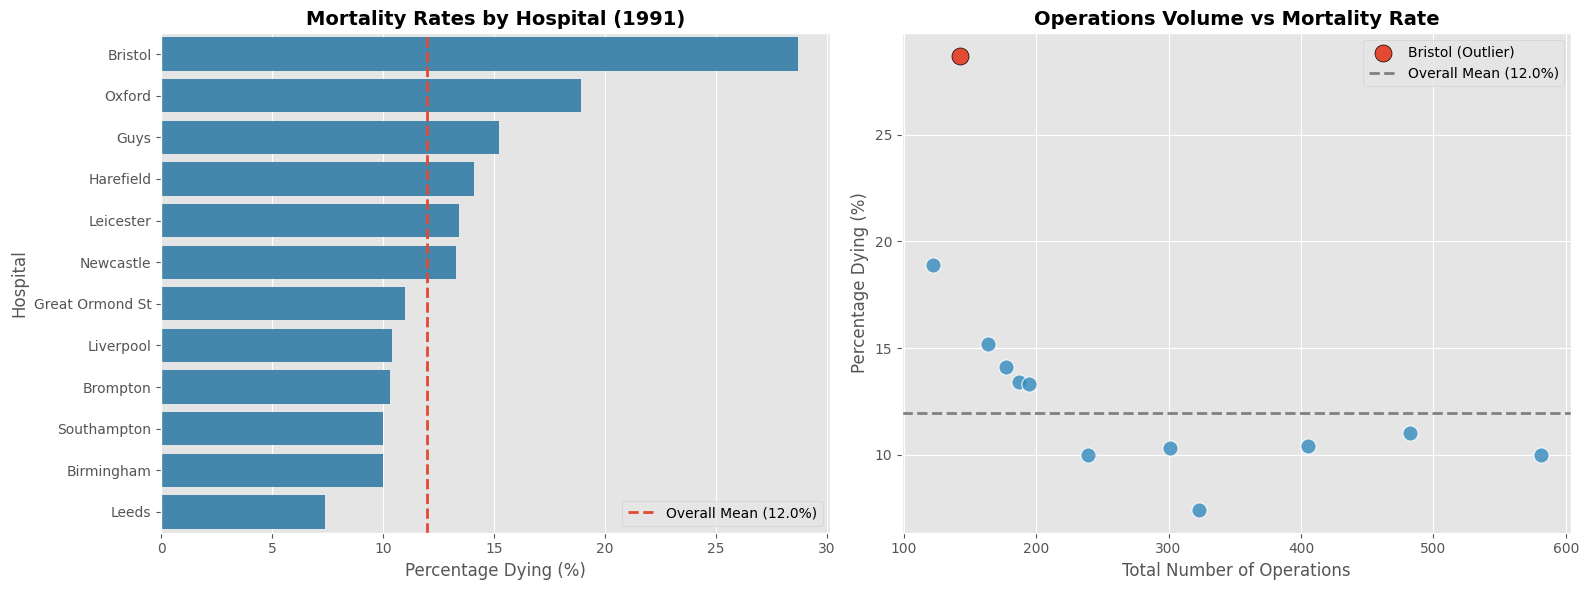

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set ggplot style for an R-like appearance
plt.style.use('ggplot')

# Load the dataset
df = pd.read_csv('child-heart-surgery-1991-x.csv')

# Calculate the overall (pooled) mortality rate across all hospitals
# Total deaths divided by total operations
overall_mean = (df['Deaths'].sum() / df['Operations'].sum()) * 100

# Sort the dataframe by mortality rate for a cleaner bar chart
df_sorted = df.sort_values('PercentageDying', ascending=False)

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PLOT 1: Horizontal Bar Chart with Mean Line
sns.barplot(
    data=df_sorted, 
    x='PercentageDying', 
    y='Hospital', 
    color='#348ABD', # Blue color
    ax=axes[0]
)

# Add a vertical dashed line representing the overall mean
axes[0].axvline(overall_mean, color='#E24A33', linestyle='--', linewidth=2, 
                label=f'Overall Mean ({overall_mean:.1f}%)')

# English labels and titles
axes[0].set_title('Mortality Rates by Hospital (1991)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Percentage Dying (%)', fontsize=12)
axes[0].set_ylabel('Hospital', fontsize=12)
axes[0].legend()

# 
# PLOT 2: Scatter Plot (Volume vs Mortality)
sns.scatterplot(
    data=df, 
    x='Operations', 
    y='PercentageDying', 
    color='#348ABD', 
    s=120, # Marker size
    alpha=0.8,
    edgecolor='white',
    ax=axes[1]
)

# Highlight Bristol specifically, as it is the historical outlier
bristol_data = df[df['Hospital'] == 'Bristol']
axes[1].scatter(
    bristol_data['Operations'], 
    bristol_data['PercentageDying'], 
    color='#E24A33', # Red color for the outlier
    s=150, 
    edgecolor='black', 
    label='Bristol (Outlier)',
    zorder=5 # Bring to front
)

# Add a horizontal dashed line representing the overall mean
axes[1].axhline(overall_mean, color='gray', linestyle='--', linewidth=2, 
                label=f'Overall Mean ({overall_mean:.1f}%)')

# English labels and titles
axes[1].set_title('Operations Volume vs Mortality Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Number of Operations', fontsize=12)
axes[1].set_ylabel('Percentage Dying (%)', fontsize=12)
axes[1].legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

## **More than one variable (Multiple Regression)**

In real life, many factors influence the outcome.  
A child's height depends not only on the father, but also on the mother,  
the child's gender, nutrition, etc.  

**Multiple Regression:** allows us to "adjust for" all of these factors at once.  
We can ask the model, "What effect does the mother's height have  
if the father's height remains constant?"

## **Different types of responses**

Regression is not just about height (continuous numbers).  

**Binary Response:** For example, will a patient survive or not?  
Logistic Regression is used for this. It does not predict a specific number,  
but the probability of an event (from 0 to 1).

## **Summary:**

**"All models are wrong, but some are useful":** This is a legendary quote from George Box.  
A model is a simplification of reality. It will never describe the world perfectly,  
but it helps us understand the underlying mechanisms.  
**Coefficients:** They indicate an expected change. If we see a change in X,  
we expect a change in Y by the magnitude of the coefficient.  
**Caution in interpretation:** A model may find a relationship, but (as we remember from Chapter 4)  
this does not always mean that one thing caused the other.